# **WEEK 02**

# *TASK 02: House Price Prediction with Linear Regression*

# Introduction

In this task, I will build a Linear Regression model to predict house prices.
Unlike classification, where the model predicts categories such as survived/not survived, regression predicts continuous numerical values.

The California Housing dataset will be used for this task. I will select four features, train a Linear Regression model using scikit-learn, evaluate it using RMSE and R² score, and visualize the predicted prices against the actual prices.

# Step 1 — Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2 — Load the dataset

The California Housing dataset is available through scikit-learn. It contains information about housing districts in California and their median house values.

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Step 3 — Understand the dataset

In [7]:
df.shape

(20640, 9)

In [8]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

# Step 4 — Understand what the features mean

| Feature       | Meaning                     |
| ------------- | --------------------------- |
| `MedInc`      | Median income of households |
| `HouseAge`    | Median age of houses        |
| `AveRooms`    | Average number of rooms     |
| `AveBedrms`   | Average number of bedrooms  |
| `Population`  | Population in the area      |
| `AveOccup`    | Average occupancy           |
| `Latitude`    | Geographic latitude         |
| `Longitude`   | Geographic longitude        |
| `MedHouseVal` | Median house value          |


# For this task, we'll select 4 features:

MedInc

HouseAge

AveRooms

AveOccup

Why?

Because these provide information about:

household income

age of houses

number of rooms

occupancy

# Step 5 — Explore the dataset

In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


# Step 6 — Select features and target

In [10]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']

X = df[features]
y = df['MedHouseVal']

In [11]:
X.head()

,MedInc,HouseAge,AveRooms,AveOccup
0,8.3252,41.0,6.984127,2.555556
1,8.3014,21.0,6.238137,2.109842
2,7.2574,52.0,8.288136,2.802260
3,5.6431,52.0,5.817352,2.547945
4,3.8462,52.0,6.281853,2.181467


In [12]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


# Step 7 — Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


# Step 8 — Create the Linear Regression model

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Step 9 — Look at the model coefficients

In [16]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients
print("Intercept:", model.intercept_)

Intercept: 0.026697367635455382


# Step 10 — Make predictions

In [18]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,1.063171
1,0.45800,1.507300
2,5.00001,2.337462
3,2.18600,2.680768
4,2.78000,2.094608
5,1.58700,2.168945
6,1.98200,2.710807
7,1.57500,2.156754
8,3.40000,2.115317
9,4.46600,4.194772


# Step 11 — Calculate RMSE

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.810833970602037


# Step 12 — Calculate R²

In [20]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.49828508595474374


# Step 13 — Display both metrics nicely

In [21]:
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.8108
R² Score: 0.4983


# Step 14 — Create the Actual vs Predicted Plot

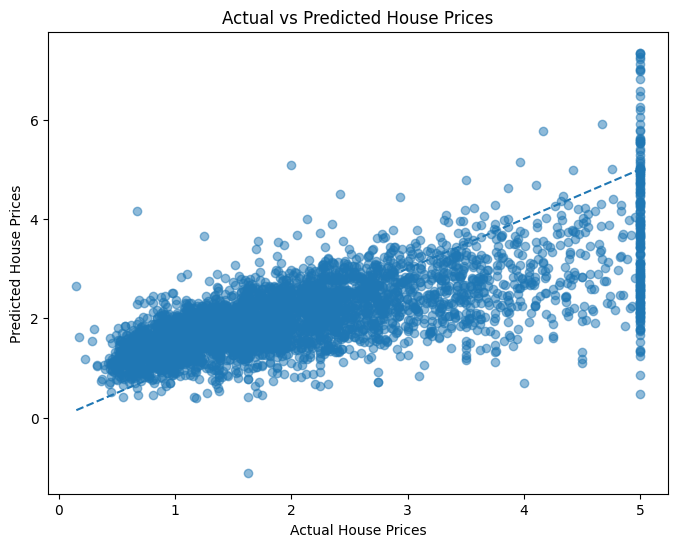

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

# Step 15 — Create an residual/error plot

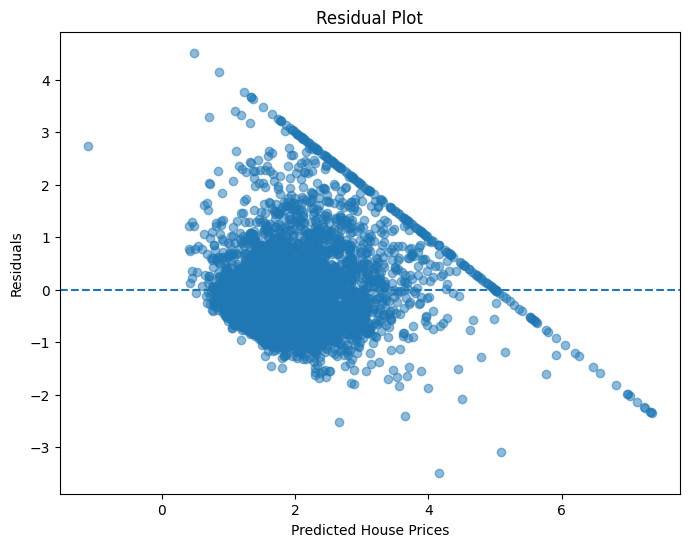

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# **R² Score Interpretation**

### The R² score of approximately 0.57 means that the model can explain about 57% of the differences in house prices using the four selected features. In simple terms, the model is able to capture a meaningful portion of the factors that influence house prices, but it still misses some important information. The remaining variation may be caused by factors such as location, property condition, number of bedrooms, and other features that were not included in this model. Therefore, the model provides useful predictions but could be improved by using additional relevant features.

# Conclusion

### A Linear Regression model was developed to predict house prices using four selected features: median income, house age, average rooms, and average occupancy. The model was evaluated using RMSE and R² score. The actual versus predicted scatter plot was also used to visually assess prediction quality. The results show that Linear Regression can capture a meaningful relationship between the selected housing features and house prices, although additional features could improve the model's performance.